## Constructing a riskless spot rate (aka zero rate) curve for USD
The first thing we need to do to price any option on a US equity is construct the so-called riskless spot rate (aka zero-rate) curve for USD. This is because pricing of derivatives is done in _the risk-neutral world_ where all investors are assumed not to require a premium for additional risks, hence future cashflows are discounted using the riskless rate to obtain the _net present value_ (NPV) of the cashflow.

I use the Fed Funds effective rate and US Treasury Yields as proxies for riskless rates. Although Treasury spot rates are not directly provided by FRED, I compute them myself by converting Treasury yields into their corresponding spot rates (aka zero-rates) using a custom module called `par_yield_converter`. Ideally, using OIS swap rates might be better as treasury spot rates tend to be slightly lower given the preferred tax treatment of treasuries. However US Treasury Yields are available for free from [FRED](https://fred.stlouisfed.org) with daily frequency while OIS swap rates are not, and the difference is pretty small. 

I use the following dataseries from FRED to accomplish the task:
* DFF &mdash; Federal Funds Effective Rate (daily frequency)
* DGS1MO &mdash; Market Yield on U.S. Treasury Securities at 1-Month Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS3MO &mdash; Market Yield on U.S. Treasury Securities at 3-Month Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS6MO &mdash; Market Yield on U.S. Treasury Securities at 6-Month Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS1 &mdash; Market Yield on U.S. Treasury Securities at 1-Year Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS2 &mdash; Market Yield on U.S. Treasury Securities at 2-Year Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS3 &mdash; Market Yield on U.S. Treasury Securities at 3-Year Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS5 &mdash; Market Yield on U.S. Treasury Securities at 5-Year Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS7 &mdash; Market Yield on U.S. Treasury Securities at 7-Year Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS10 &mdash; Market Yield on U.S. Treasury Securities at 10-Year Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS20 &mdash; Market Yield on U.S. Treasury Securities at 20-Year Constant Maturity, Quoted on an Investment Basis (daily frequency)
* DGS30 &mdash; Market Yield on U.S. Treasury Securities at 30-Year Constant Maturity, Quoted on an Investment Basis (daily frequency)

In the `pricing.curves.YieldCurve` class I use cubic splines by default to interpolate when constructing the curve. See [this article](http://web.math.ku.dk/~rolf/HaganWest.pdf) for more details on interpolation methods if you want to know more. Cubic splines is pretty advanced.

In [1]:
# Uncomment if running in Google Colaboratory, otherwise the import of the curves module in the cell below will fail
#!git clone -l -s https://github.com/ilchen/options-pricing.git cloned-repo
#%cd cloned-repo

# Install the latest version of pandas datareader
#!pip install pyfredapi -U

# import os
# os.environ["FRED_API_KEY"] = "your_actual_key_here" # or store it in Colab Secrets (better)

In [2]:
import locale
from datetime import date, datetime

from dateutil.relativedelta import relativedelta
import pyfredapi as pf
import yfinance as yfin
from pandas.tseries.offsets import BDay
import numpy as np
import pandas as pd

from volatility import parameter_estimators, volatility_trackers
from pricing import curves, options, par_yield_converter

_ = locale.setlocale(locale.LC_ALL, '')

In [3]:
today = date.today()

# Constructing the riskless yield curve based on the current Fed funds rate and treasury yields
# data = web.get_data_fred(
#     ['DFF', 'DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30'],
#     today - BDay(3), today)
# data.dropna(inplace=True)

collection = pf.series_collection.SeriesCollection(
    series_id=['DFF', 'DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30'],
    observation_start=(today - BDay(3)).strftime('%Y-%m-%d')
)
# Convert to wide DataFrame
data = collection.merge_wide().set_index('date')

cur_date_curve = data.index[-1].date()

# Convert to percentage points
data /= 100.

# Some adjustments are required to bring FED Funds rate to the same day count convention and compounding frequency
# as treasury yields (actual/actual with semi-annual compounding):
# 1. https://www.federalreserve.gov/releases/h15/default.htm -> day count convention for Fed Funds Rate needs
# to be changed to actual/actual
# 2. Conversion to APY: https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics/interest-rates-frequently-asked-questions
data.DFF *= (366 if curves.YieldCurve.is_leap_year(cur_date_curve.year) else 365) / 360 # to x/actual
data.DFF = 2 * (np.sqrt(data.DFF + 1) - 1)

maturities = [0, 1/12, .25, .5, 1, 2, 3, 5, 7, 10, 20, 30]
offsets = [relativedelta(), relativedelta(months=+1), relativedelta(months=+3), relativedelta(months=+6),
           relativedelta(years=+1), relativedelta(years=+2), relativedelta(years=+3), relativedelta(years=+5),
           relativedelta(years=+7), relativedelta(years=+10), relativedelta(years=+20),
           relativedelta(years=+30)]

spot_rates_dict = par_yield_converter.par_yields_to_spot(data.loc[pd.Timestamp(cur_date_curve)], maturities, 2)
spot_rates = np.asarray([spot_rates_dict[maturity] for maturity in maturities], dtype=np.float64)

# Define the riskless yield curve
curve_ = curves.YieldCurve(today, offsets, data.loc[pd.Timestamp(cur_date_curve)], compounding_freq=2)

# Define the riskless spot rate curve
curve = curves.YieldCurve(today, offsets, spot_rates, compounding_freq=2)

Requesting series DFF...
Requesting series DGS1MO...
Requesting series DGS3MO...
Requesting series DGS6MO...
Requesting series DGS1...
Requesting series DGS2...
Requesting series DGS3...
Requesting series DGS5...
Requesting series DGS7...
Requesting series DGS10...
Requesting series DGS20...
Requesting series DGS30...


### Optional: Visualizing the riskless spot rate and yield curves for USD

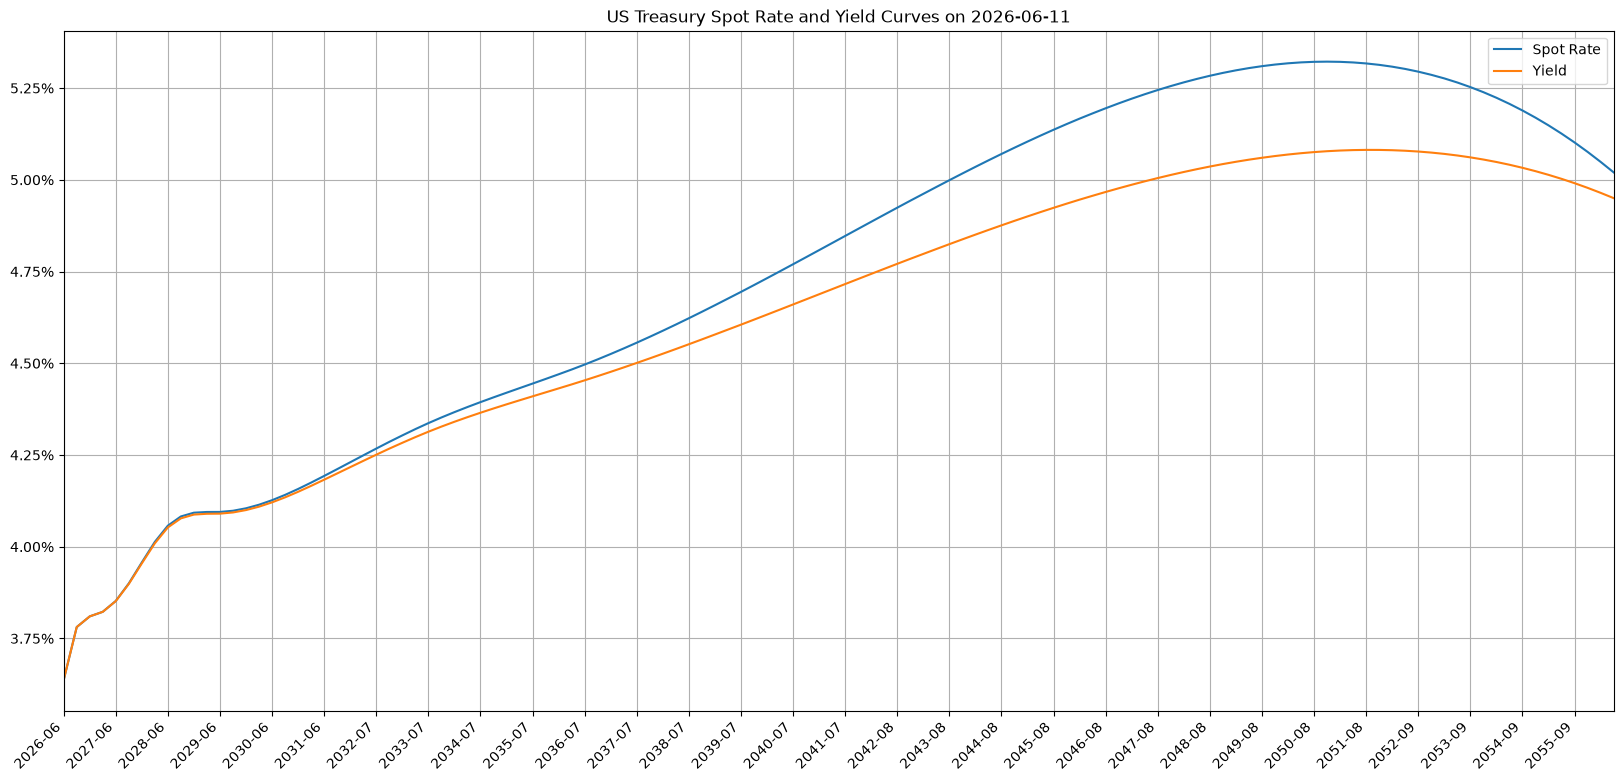

In [4]:
import matplotlib.ticker as mtick
curve_points = curve.get_curve_points(120)
curve_points_ = curve_.get_curve_points(120)
ax = curve_points.plot(figsize=(20,10), grid=True, xlim=(curve_points.index[0], curve_points.index[-1]),
                       xticks=curve_points.index[::4], xlabel='', rot=45)
curve_points_.plot(figsize=(20,10), grid=True, xlim=(curve_points_.index[0], curve_points.index[-1]),
                   xticks=curve_points_.index[::4], xlabel='', rot=45)
ax.set_title('US Treasury Spot Rate and Yield Curves on ' + cur_date_curve.strftime('%Y-%m-%d'))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
h, _ = ax.get_legend_handles_labels()
ax.legend(h, ['Spot Rate', 'Yield'])
_ = ax.set_xticklabels(list(map(lambda x: x.strftime('%Y-%m'), curve_points.index[::4])))

In [5]:
assert curve.date == BDay(1).rollforward(today).date()